# Orthogonal Matching Pursuit

OMP greedily builds sparse approximations by repeatedly selecting the atom most correlated with the residual and refitting coefficients by least squares.
At step $k$:
$$
j_k=\arg\max_j |\langle a_j, r_{k-1}\rangle|,\qquad
x_{S_k}=\arg\min_z\|A_{S_k}z-y\|_2^2.
$$


## Environment

We load numerical tools and define a notebook-local output directory for generated figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/orthogonal-matching-pursuit") if Path("python/orthogonal-matching-pursuit").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Numerical Experiment

We implement the core algorithm and generate comparative visuals to expose behavior clearly.


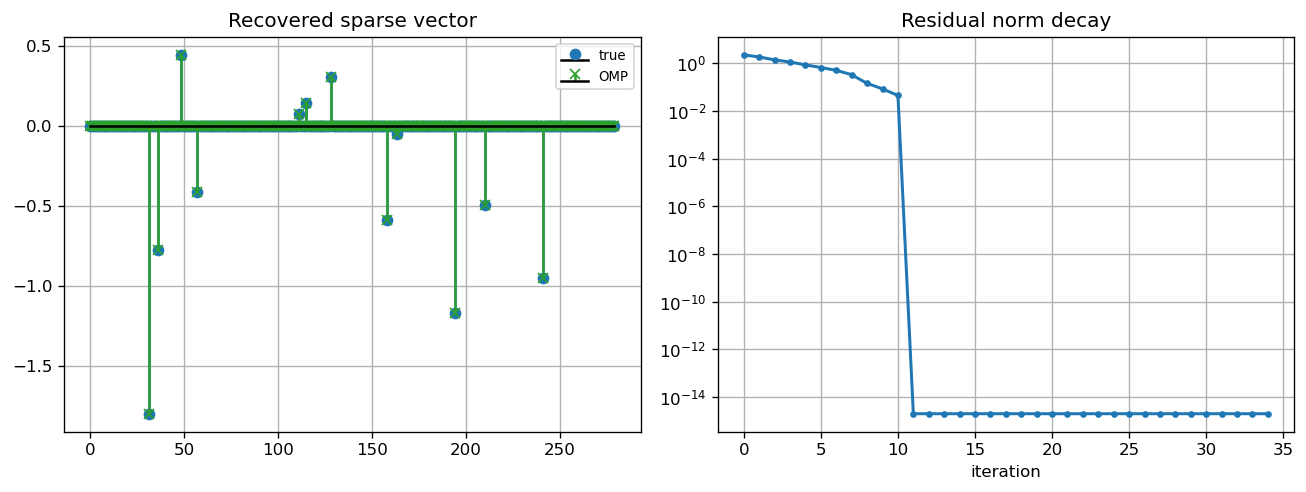

In [2]:
rng = np.random.default_rng(1)
m, n = 90, 280
s = 12
A = rng.standard_normal((m, n)); A /= np.linalg.norm(A, axis=0, keepdims=True) + 1e-12
x_true = np.zeros(n)
supp = rng.choice(n, s, replace=False)
x_true[supp] = rng.standard_normal(s)
y = A @ x_true

S = []
r = y.copy()
x = np.zeros(n)
res = []
for _ in range(35):
    j = int(np.argmax(np.abs(A.T @ r)))
    if j not in S:
        S.append(j)
    As = A[:, S]
    coef, *_ = np.linalg.lstsq(As, y, rcond=None)
    x[:] = 0
    x[np.array(S)] = coef
    r = y - A @ x
    res.append(np.linalg.norm(r))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].stem(x_true, linefmt="C0-", markerfmt="C0o", basefmt="k-", label="true")
axes[0].stem(x, linefmt="C2-", markerfmt="C2x", basefmt="k-", label="OMP")
axes[0].set_title("Recovered sparse vector"); axes[0].legend(fontsize=8)
axes[1].plot(res, "-o", lw=1.8, ms=3); axes[1].set_yscale("log")
axes[1].set_title("Residual norm decay"); axes[1].set_xlabel("iteration")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- J. Nocedal and S. Wright, *Numerical Optimization*.
- L. N. Trefethen, *Finite Difference and Spectral Methods* (lecture notes).
- D. P. Bertsekas, *Nonlinear Programming*.
